# TARNet: Any Email vs. No Email

This notebook implements TARNet using the same binary treatment definition as the causal-forest baseline and the ATARNet models:

- **Control:** no email
- **Treatment:** men's or women's email

The shared network learns a customer representation. Two outcome heads estimate the probability of a visit with and without treatment, and their difference is the predicted individual uplift.

## 1. Setup

The data split and training protocol match the head-specific ATARNet notebook so the final comparison focuses on the model architecture.

In [24]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

In [25]:
seed = 123
split_seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# This avoids a native thread conflict in some macOS PyTorch environments.
torch.set_num_threads(1)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.2.2
Device: mps


## 2. Load and split the data

Like ATARNet, TARNet uses an 80/20 split with `random_state=42` and stratification by binary treatment. The entire 80% training portion is used for optimization.

In [26]:
data_path = Path("../data/raw/hillstrom_email.csv")
if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at {data_path.resolve()}")

df = pd.read_csv(data_path)
print(f"Loaded {data_path.name} with shape {df.shape}")

df.groupby("segment")["visit"].agg(customers="size", visit_rate="mean")

Loaded hillstrom_email.csv with shape (64000, 12)


,customers,visit_rate
segment,,
Mens E-Mail,21307,0.182757
No E-Mail,21306,0.106167
Womens E-Mail,21387,0.151400


In [27]:
numerical_columns = ["recency", "history", "mens", "womens"]
categorical_columns = ["history_segment", "zip_code", "newbie", "channel"]
outcome_column = "visit"

# Match the treatment definition used by the baseline and ATARNet notebooks.
df["treatment"] = (df["segment"] != "No E-Mail").astype(int)

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=split_seed,
    stratify=df["treatment"],
)

train_df = train_df.copy()
test_df = test_df.copy()

print("Training rows:", len(train_df))
print("Testing rows: ", len(test_df))

Training rows: 51200
Testing rows:  12800


In [28]:
split_summary = []
for split_name, split_df in {"train": train_df, "test": test_df}.items():
    summary = (
        split_df.groupby("treatment")[outcome_column]
        .agg(customers="size", visit_rate="mean")
        .reset_index()
    )
    summary["group"] = summary["treatment"].map(
        {0: "No E-Mail", 1: "Any E-Mail"}
    )
    summary.insert(0, "split", split_name)
    split_summary.append(summary)

pd.concat(split_summary, ignore_index=True)[
    ["split", "group", "customers", "visit_rate"]
]

,split,group,customers,visit_rate
0,train,No E-Mail,17045,0.105837
1,train,Any E-Mail,34155,0.166916
2,test,No E-Mail,4261,0.107487
3,test,Any E-Mail,8539,0.167584


## 3. Preprocess features

Numeric features are standardized. Each categorical feature is converted to integer IDs and later receives its own learned embedding. ID zero is reserved for an unseen category so the model can safely score new data.

In [29]:
scaler = StandardScaler()
scaler.fit(train_df[numerical_columns])

category_mappings = {}
categorical_cardinalities = []

for column in categorical_columns:
    categories = train_df[column].unique().tolist()
    category_mappings[column] = {
        category: index for index, category in enumerate(categories)
    }
    categorical_cardinalities.append(len(categories))

print("Categorical cardinalities:", categorical_cardinalities)

Categorical cardinalities: [7, 3, 2, 3]


In [30]:
def make_tensors(frame):
    numeric = scaler.transform(frame[numerical_columns])

    categorical_parts = []
    for column in categorical_columns:
        ids = frame[column].map(category_mappings[column]).to_numpy()
        if pd.isna(ids).any():
            raise ValueError(f"Unseen category found in {column}")
        categorical_parts.append(ids)

    categorical = np.column_stack(categorical_parts)
    treatment = frame["treatment"].to_numpy()
    outcome = frame[outcome_column].to_numpy()

    return TensorDataset(
        torch.tensor(numeric, dtype=torch.float32),
        torch.tensor(categorical, dtype=torch.long),
        torch.tensor(treatment, dtype=torch.long),
        torch.tensor(outcome, dtype=torch.float32),
    )


train_dataset = make_tensors(train_df)
test_dataset = make_tensors(test_df)

generator = torch.Generator()
generator.manual_seed(seed)
batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=generator,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

next(iter(train_loader))[0].shape

torch.Size([256, 4])

## 4. TARNet architecture

The model has three parts:

1. **Feature encoder:** combines standardized numeric values with learned categorical embeddings.
2. **Shared representation:** residual fully connected blocks learn customer patterns that are useful under both treatment conditions.
3. **Outcome heads:** one head estimates visits under control and the other estimates visits under treatment.

Only the head matching a customer's observed treatment contributes to the factual training loss. The other output is that customer's counterfactual prediction.

In [31]:
class FeatureEncoder(nn.Module):
    def __init__(self, num_numeric, category_sizes, embedding_dim=4):
        super().__init__()
        self.embeddings = nn.ModuleList(
            [nn.Embedding(size, embedding_dim) for size in category_sizes]
        )
        self.output_dim = num_numeric + len(category_sizes) * embedding_dim

    def forward(self, numeric, categorical):
        embedded = [
            embedding(categorical[:, index])
            for index, embedding in enumerate(self.embeddings)
        ]
        return torch.cat([numeric, *embedded], dim=1)


class ResidualBlock(nn.Module):
    def __init__(self, width, dropout):
        super().__init__()
        self.block = nn.Sequential(
            nn.LayerNorm(width),
            nn.Linear(width, width * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(width * 2, width),
        )

    def forward(self, inputs):
        return inputs + self.block(inputs)


class OutcomeHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, representation):
        return self.network(representation)


class TARNet(nn.Module):
    def __init__(
        self,
        num_numeric,
        category_sizes,
        num_treatments,
        embedding_dim=4,
        shared_width=128,
        representation_dim=64,
        head_width=32,
        dropout=0.15,
    ):
        super().__init__()
        self.encoder = FeatureEncoder(
            num_numeric=num_numeric,
            category_sizes=category_sizes,
            embedding_dim=embedding_dim,
        )
        self.shared_network = nn.Sequential(
            nn.Linear(self.encoder.output_dim, shared_width),
            nn.GELU(),
            ResidualBlock(shared_width, dropout),
            ResidualBlock(shared_width, dropout),
            nn.LayerNorm(shared_width),
            nn.Linear(shared_width, representation_dim),
            nn.GELU(),
        )
        self.outcome_heads = nn.ModuleList(
            [
                OutcomeHead(representation_dim, head_width, dropout)
                for _ in range(num_treatments)
            ]
        )

    def forward(self, numeric, categorical):
        features = self.encoder(numeric, categorical)
        representation = self.shared_network(features)
        logits = [head(representation) for head in self.outcome_heads]
        return torch.cat(logits, dim=1)


def factual_loss(all_logits, treatment, outcome):
    factual_logits = all_logits.gather(1, treatment.unsqueeze(1)).squeeze(1)
    return nn.functional.binary_cross_entropy_with_logits(factual_logits, outcome)

In [32]:
model = TARNet(
    num_numeric=len(numerical_columns),
    category_sizes=categorical_cardinalities,
    num_treatments=2,
).to(device)

number_of_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)

sample_numeric, sample_categorical, sample_treatment, sample_outcome = next(
    iter(train_loader)
)
with torch.no_grad():
    sample_logits = model(
        sample_numeric[:8].to(device),
        sample_categorical[:8].to(device),
    )

print(model)
print(f"\nTrainable parameters: {number_of_parameters:,}")
print("Output shape:", sample_logits.shape)

TARNet(
  (encoder): FeatureEncoder(
    (embeddings): ModuleList(
      (0): Embedding(7, 4)
      (1): Embedding(3, 4)
      (2): Embedding(2, 4)
      (3): Embedding(3, 4)
    )
  )
  (shared_network): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): ResidualBlock(
      (block): Sequential(
        (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (1): Linear(in_features=128, out_features=256, bias=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.15, inplace=False)
        (4): Linear(in_features=256, out_features=128, bias=True)
      )
    )
    (3): ResidualBlock(
      (block): Sequential(
        (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (1): Linear(in_features=128, out_features=256, bias=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.15, inplace=False)
        (4): Linear(in_features=256, out_features=128, bias=True)
      )
  

## 5. Train the model

For direct comparison, this uses the same optimizer and schedule as ATARNet: Adam with learning rate `0.0005`, factual binary cross-entropy, batch size `256`, and 20 epochs. There is no validation split, learning-rate scheduler, weight decay, gradient clipping, or early stopping.

In [33]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

number_of_epochs = 20
train_losses = []

for epoch in range(number_of_epochs):
    model.train()
    total_loss = 0.0

    for numeric, categorical, treatment, outcome in train_loader:
        numeric = numeric.to(device)
        categorical = categorical.to(device)
        treatment = treatment.to(device)
        outcome = outcome.to(device)

        optimizer.zero_grad()
        logits = model(numeric, categorical)
        loss = factual_loss(logits, treatment, outcome)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(outcome)

    average_train_loss = total_loss / len(train_dataset)
    train_losses.append(average_train_loss)

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Training loss: {average_train_loss:.4f}"
    )

Epoch 01 | Training loss: 0.4199
Epoch 02 | Training loss: 0.4032
Epoch 03 | Training loss: 0.4030
Epoch 04 | Training loss: 0.4031
Epoch 05 | Training loss: 0.4022
Epoch 06 | Training loss: 0.4018
Epoch 07 | Training loss: 0.4019
Epoch 08 | Training loss: 0.4015
Epoch 09 | Training loss: 0.4012
Epoch 10 | Training loss: 0.4010
Epoch 11 | Training loss: 0.4012
Epoch 12 | Training loss: 0.4011
Epoch 13 | Training loss: 0.4004
Epoch 14 | Training loss: 0.4005
Epoch 15 | Training loss: 0.4008
Epoch 16 | Training loss: 0.4003
Epoch 17 | Training loss: 0.4003
Epoch 18 | Training loss: 0.3998
Epoch 19 | Training loss: 0.3997
Epoch 20 | Training loss: 0.3997


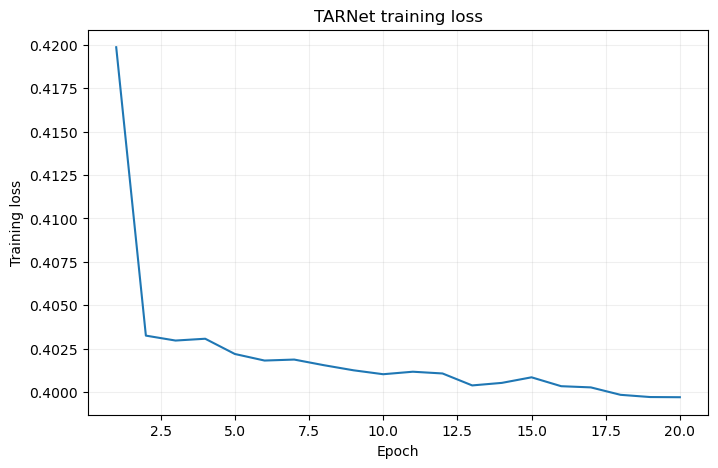

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, number_of_epochs + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("TARNet training loss")
plt.grid(alpha=0.2)
plt.show()

## 6. Generate potential outcomes

Each customer receives two predicted visit probabilities: one under no email and one under any email. We evaluate ordinary prediction only on the treatment that was actually observed. The other potential outcome is unobservable for that customer.

In [35]:
def predict_potential_outcomes(model, data_loader):
    model.eval()
    probabilities = []
    treatments = []
    outcomes = []

    with torch.no_grad():
        for numeric, categorical, treatment, outcome in data_loader:
            logits = model(numeric.to(device), categorical.to(device))
            probabilities.append(torch.sigmoid(logits).cpu())
            treatments.append(treatment)
            outcomes.append(outcome)

    return (
        torch.cat(probabilities).numpy(),
        torch.cat(treatments).numpy(),
        torch.cat(outcomes).numpy(),
    )


potential_outcomes, test_treatment, test_outcome = predict_potential_outcomes(
    model,
    test_loader,
)

factual_probability = potential_outcomes[
    np.arange(len(test_treatment)), test_treatment
]

print("Test log loss:", round(log_loss(test_outcome, factual_probability), 4))
print("Test ROC AUC: ", round(roc_auc_score(test_outcome, factual_probability), 4))
print("Test Brier score:", round(np.mean((test_outcome - factual_probability) ** 2), 4))

Test log loss: 0.4024
Test ROC AUC:  0.6426
Test Brier score: 0.122


In [36]:
results = test_df.reset_index(drop=True).copy()
results["pred_control"] = potential_outcomes[:, 0]
results["pred_treatment"] = potential_outcomes[:, 1]
results["predicted_uplift"] = (
    results["pred_treatment"] - results["pred_control"]
)

calibration_rows = []
for treatment_id, group_name in [(0, "No E-Mail"), (1, "Any E-Mail")]:
    mask = test_treatment == treatment_id
    calibration_rows.append(
        {
            "group": group_name,
            "customers": int(mask.sum()),
            "observed_visit_rate": test_outcome[mask].mean(),
            "average_factual_prediction": factual_probability[mask].mean(),
        }
    )

pd.DataFrame(calibration_rows)

,group,customers,observed_visit_rate,average_factual_prediction
0,No E-Mail,4261,0.107487,0.111537
1,Any E-Mail,8539,0.167584,0.165390


In [37]:
control_rate = results.loc[results["treatment"] == 0, outcome_column].mean()
treatment_rate = results.loc[results["treatment"] == 1, outcome_column].mean()
randomized_test_ate = treatment_rate - control_rate

effect_summary = pd.DataFrame(
    {
        "randomized_test_ATE": [randomized_test_ate],
        "average_predicted_uplift": [results["predicted_uplift"].mean()],
        "median_predicted_uplift": [results["predicted_uplift"].median()],
        "minimum_predicted_uplift": [results["predicted_uplift"].min()],
        "maximum_predicted_uplift": [results["predicted_uplift"].max()],
    }
)

effect_summary

,randomized_test_ATE,average_predicted_uplift,median_predicted_uplift,minimum_predicted_uplift,maximum_predicted_uplift
0,0.060098,0.052131,0.051414,-0.058402,0.248426


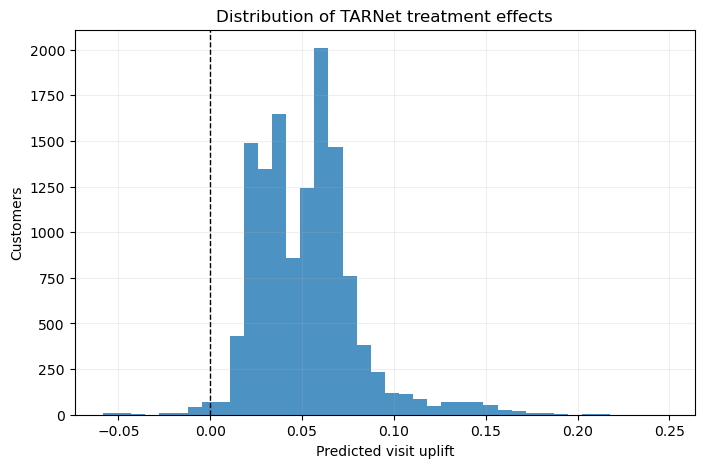

In [38]:
plt.figure(figsize=(8, 5))
plt.hist(results["predicted_uplift"], bins=40, alpha=0.8)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Predicted visit uplift")
plt.ylabel("Customers")
plt.title("Distribution of TARNet treatment effects")
plt.grid(alpha=0.2)
plt.show()

## 7. Uplift evaluation

True individual treatment effects are not observable, so classification accuracy alone cannot validate uplift. We rank the randomized test set by predicted uplift and estimate cumulative incremental visits with inverse-propensity weighting.

- **AUUC** measures the area under the cumulative uplift curve.
- **Qini coefficient** measures the area between the model's curve and random targeting.
- **Top-k uplift** estimates the visit-rate increase among the highest-ranked 5%, 10%, and 20% of customers.

Higher values are better. These estimates can still be noisy because evaluation uses observed treatment assignments rather than known counterfactual outcomes.

In [39]:
def uplift_curve(frame):
    ranked = frame.sort_values(
        "predicted_uplift", ascending=False
    ).reset_index(drop=True)

    treated = ranked["treatment"].to_numpy(dtype=float)
    outcome = ranked[outcome_column].to_numpy(dtype=float)
    propensity = treated.mean()

    # Random treatment assignment supports this IPW estimate of incremental visits.
    contribution = outcome * (
        treated / propensity - (1 - treated) / (1 - propensity)
    )
    cumulative_gain = np.concatenate(
        [[0.0], np.cumsum(contribution) / len(ranked)]
    )
    fraction_targeted = np.linspace(0, 1, len(cumulative_gain))
    random_gain = fraction_targeted * cumulative_gain[-1]

    return {
        "ranked": ranked,
        "contribution": contribution,
        "fraction_targeted": fraction_targeted,
        "cumulative_gain": cumulative_gain,
        "random_gain": random_gain,
        "AUUC": np.trapz(cumulative_gain, fraction_targeted),
        "Qini_coefficient": np.trapz(
            cumulative_gain - random_gain, fraction_targeted
        ),
    }


curve_results = uplift_curve(results)

pd.DataFrame(
    {
        "AUUC": [curve_results["AUUC"]],
        "Qini_coefficient": [curve_results["Qini_coefficient"]],
    }
)

,AUUC,Qini_coefficient
0,0.034985,0.004937


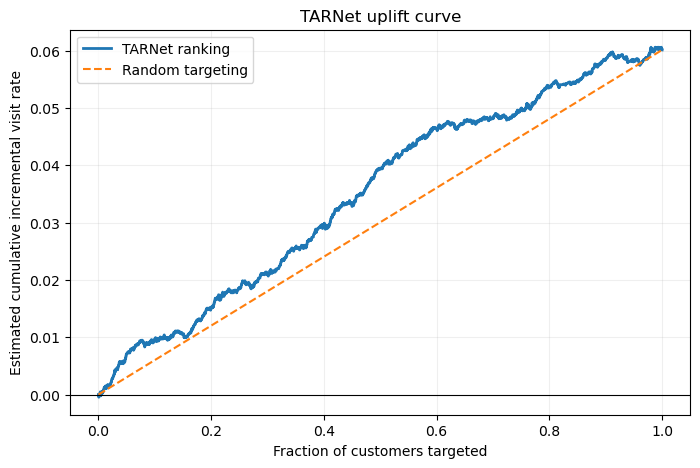

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(
    curve_results["fraction_targeted"],
    curve_results["cumulative_gain"],
    label="TARNet ranking",
    linewidth=2,
)
plt.plot(
    curve_results["fraction_targeted"],
    curve_results["random_gain"],
    label="Random targeting",
    linestyle="--",
)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Fraction of customers targeted")
plt.ylabel("Estimated cumulative incremental visit rate")
plt.title("TARNet uplift curve")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

In [41]:
targeting_rows = []
contribution = curve_results["contribution"]

for fraction in [0.05, 0.10, 0.20]:
    number_targeted = int(np.ceil(len(contribution) * fraction))
    estimated_uplift = contribution[:number_targeted].mean()
    targeting_rows.append(
        {
            "target_fraction": fraction,
            "customers_in_evaluation": number_targeted,
            "estimated_visit_uplift": estimated_uplift,
            "incremental_visits_per_1000": 1000 * estimated_uplift,
        }
    )

targeting_results = pd.DataFrame(targeting_rows)
targeting_results

,target_fraction,customers_in_evaluation,estimated_visit_uplift,incremental_visits_per_1000
0,0.05,640,0.142612,142.612224
1,0.10,1280,0.096949,96.948773
2,0.20,2560,0.075297,75.297490
